# Simulação de Preço de Ativo — Monte Carlo

Este notebook simula trajetórias futuras de preços usando o modelo de **Movimento Geométrico Browniano (GBM)**, o mesmo utilizado como base do modelo **Black-Scholes** na precificação de opções.

---

### Conceito central

O preço evolui de acordo com a equação:

$$S_{t+1} = S_t \cdot \exp\left(\left(\mu - \frac{\sigma^2}{2}\right)dt + \sigma\sqrt{dt}\cdot Z\right)$$

onde:
- $\mu$ = drift (retorno médio anual)
- $\sigma$ = volatilidade anual
- $Z \sim \mathcal{N}(0,1)$ = choque aleatório a cada passo
- $dt = 1$ dia

---

### Fluxo do notebook

1. **Instalar dependências**
2. **Configurar parâmetros** — escolha o ativo e o horizonte
3. **Baixar dados históricos** — calibra μ e σ automaticamente
4. **Rodar as simulações** — 1.000 trajetórias GBM
5. **Visualizar resultados** — painel completo com métricas

## 1 · Instalar dependências

In [23]:
# Instala o yfinance (único pacote não nativo do Colab)
%pip install yfinance --quiet

## 2 · Imports

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import yfinance as yf
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings("ignore")

## 3 · Parâmetros

> **Edite esta célula** para trocar o ativo ou o horizonte de simulação.

| Parâmetro | Exemplos |
|---|---|
| `TICKER` | `PETR4.SA`, `VALE3.SA`, `AAPL`, `ENI.MI`, `MSFT` |
| `DIAS_SIMULACAO` | `63` (3 meses), `126` (6 meses), `252` (1 ano) |
| `N_SIMULACOES` | `500` (rápido), `1000` (padrão), `5000` (preciso) |

In [25]:
# ─────────────────────────────────────────────────────────
#    EDITE AQUI
# ─────────────────────────────────────────────────────────
TICKER         = "PETR4.SA"   # Código do ativo no Yahoo Finance
ANOS_HISTORICO = 2             # Anos de histórico para calibrar μ e σ
DIAS_SIMULACAO = 252           # Horizonte: 252 = 1 ano útil
N_SIMULACOES   = 1000          # Número de trajetórias Monte Carlo
SEMENTE        = 42            # Semente (garante reprodutibilidade)
# ─────────────────────────────────────────────────────────

print(f"Ativo selecionado : {TICKER}")
print(f"Horizonte         : {DIAS_SIMULACAO} dias")
print(f"Simulações        : {N_SIMULACOES:,}")

Ativo selecionado : PETR4.SA
Horizonte         : 252 dias
Simulações        : 1,000


## 4 · Funções do modelo

Aqui estão as 4 funções que compõem o pipeline:

| Função | O que faz |
|---|---|
| `baixar_dados()` | Busca preços históricos via yfinance |
| `calcular_parametros()` | Estima μ e σ com retornos log-diários |
| `simular_gbm()` | Núcleo do Monte Carlo — gera as trajetórias |
| `calcular_estatisticas()` | Calcula VaR, prob. de lucro, percentis |

In [26]:
def baixar_dados(ticker: str, anos: int) -> pd.Series:
    """Baixa preços de fechamento ajustados via yfinance."""
    fim    = datetime.today()
    inicio = fim - timedelta(days=int(anos * 365.25))
    df = yf.download(ticker, start=inicio, end=fim, progress=False, auto_adjust=True)
    if df.empty:
        raise ValueError(f"Nenhum dado encontrado para '{ticker}'.")
    precos = df["Close"].squeeze()
    print(f"✓ {ticker}: {len(precos)} dias  |  {precos.index[0].date()} → {precos.index[-1].date()}")
    return precos


def calcular_parametros(precos: pd.Series):
    """
    Estima μ e σ a partir dos retornos log-diários.
    Retorna: (mu_diario, sigma_diario, S0)
    """
    retornos_log = np.log(precos / precos.shift(1)).dropna()
    mu_diario    = float(retornos_log.mean())   # drift médio diário
    sigma_diario = float(retornos_log.std())    # volatilidade diária
    S0           = float(precos.iloc[-1])       # preço mais recente

    print(f"\n{'─'*42}")
    print(f"  Preço atual  (S₀) : R$ {S0:.2f}")
    print(f"  Drift  (μ anual)  : {mu_diario * 252 * 100:.1f}%")
    print(f"  Volat. (σ anual)  : {sigma_diario * np.sqrt(252) * 100:.1f}%")
    print(f"{'─'*42}")
    return mu_diario, sigma_diario, S0


def simular_gbm(S0: float, mu: float, sigma: float,
                T: int, N: int, seed: int) -> np.ndarray:
    """
    Simula N trajetórias de preços com o modelo GBM.

    Fórmula:
        S(t+1) = S(t) * exp( (μ - σ²/2) + σ * Z )
        Z ~ N(0,1)

    Retorna ndarray de forma (T+1, N).
    """
    np.random.seed(seed)

    # Choques aleatórios: shape (T, N)
    Z = np.random.standard_normal((T, N))

    # Retorno diário pela fórmula GBM
    retornos = np.exp((mu - 0.5 * sigma**2) + sigma * Z)

    # Constrói as trajetórias via produto acumulado
    trajetorias = np.zeros((T + 1, N))
    trajetorias[0] = S0
    for t in range(1, T + 1):
        trajetorias[t] = trajetorias[t - 1] * retornos[t - 1]

    return trajetorias


def calcular_estatisticas(trajetorias: np.ndarray, S0: float) -> dict:
    """Calcula métricas-chave a partir dos preços finais simulados."""
    pf = trajetorias[-1]  # preços finais
    return {
        "media"            : float(np.mean(pf)),
        "mediana"          : float(np.median(pf)),
        "std"              : float(np.std(pf)),
        "p5"               : float(np.percentile(pf, 5)),
        "p25"              : float(np.percentile(pf, 25)),
        "p75"              : float(np.percentile(pf, 75)),
        "p95"              : float(np.percentile(pf, 95)),
        "retorno_esperado" : float((np.mean(pf) / S0 - 1) * 100),
        "prob_lucro"       : float(np.mean(pf > S0) * 100),
        "prob_queda_20"    : float(np.mean(pf < S0 * 0.80) * 100),
        "var_95"           : float((np.percentile(pf, 5) / S0 - 1) * 100),
    }

## 5 · Executar simulação

In [27]:
# ── Passo 1: dados históricos
precos = baixar_dados(TICKER, ANOS_HISTORICO)

# ── Passo 2: calibrar μ e σ
mu, sigma, S0 = calcular_parametros(precos)

# ── Passo 3: Monte Carlo
print(f"\n→ Rodando {N_SIMULACOES:,} simulações × {DIAS_SIMULACAO} dias...")
trajetorias = simular_gbm(S0, mu, sigma, DIAS_SIMULACAO, N_SIMULACOES, SEMENTE)
print("✓ Concluído!")

# ── Passo 4: estatísticas
stats = calcular_estatisticas(trajetorias, S0)

print(f"\n{'─'*42}")
print(f"  Retorno esperado  : {stats['retorno_esperado']:+.1f}%")
print(f"  Prob. de lucro    : {stats['prob_lucro']:.1f}%")
print(f"  VaR 95%           : {stats['var_95']:.1f}%")
print(f"  P5 → P95          : R$ {stats['p5']:.2f} → R$ {stats['p95']:.2f}")
print(f"{'─'*42}")

✓ PETR4.SA: 500 dias  |  2024-04-08 → 2026-04-07

──────────────────────────────────────────
  Preço atual  (S₀) : R$ 49.32
  Drift  (μ anual)  : 28.0%
  Volat. (σ anual)  : 23.6%
──────────────────────────────────────────

→ Rodando 1,000 simulações × 252 dias...
✓ Concluído!

──────────────────────────────────────────
  Retorno esperado  : +32.5%
  Prob. de lucro    : 84.6%
  VaR 95%           : -12.6%
  P5 → P95          : R$ 43.12 → R$ 94.18
──────────────────────────────────────────


## 6 · Visualização

O painel tem **3 seções**:
- **Topo** — todas as trajetórias simuladas com banda de confiança P5–P95 e mediana em destaque
- **Inferior esquerda** — histograma dos preços finais (verde = lucro, vermelho = perda)
- **Inferior direita** — tabela de métricas resumidas

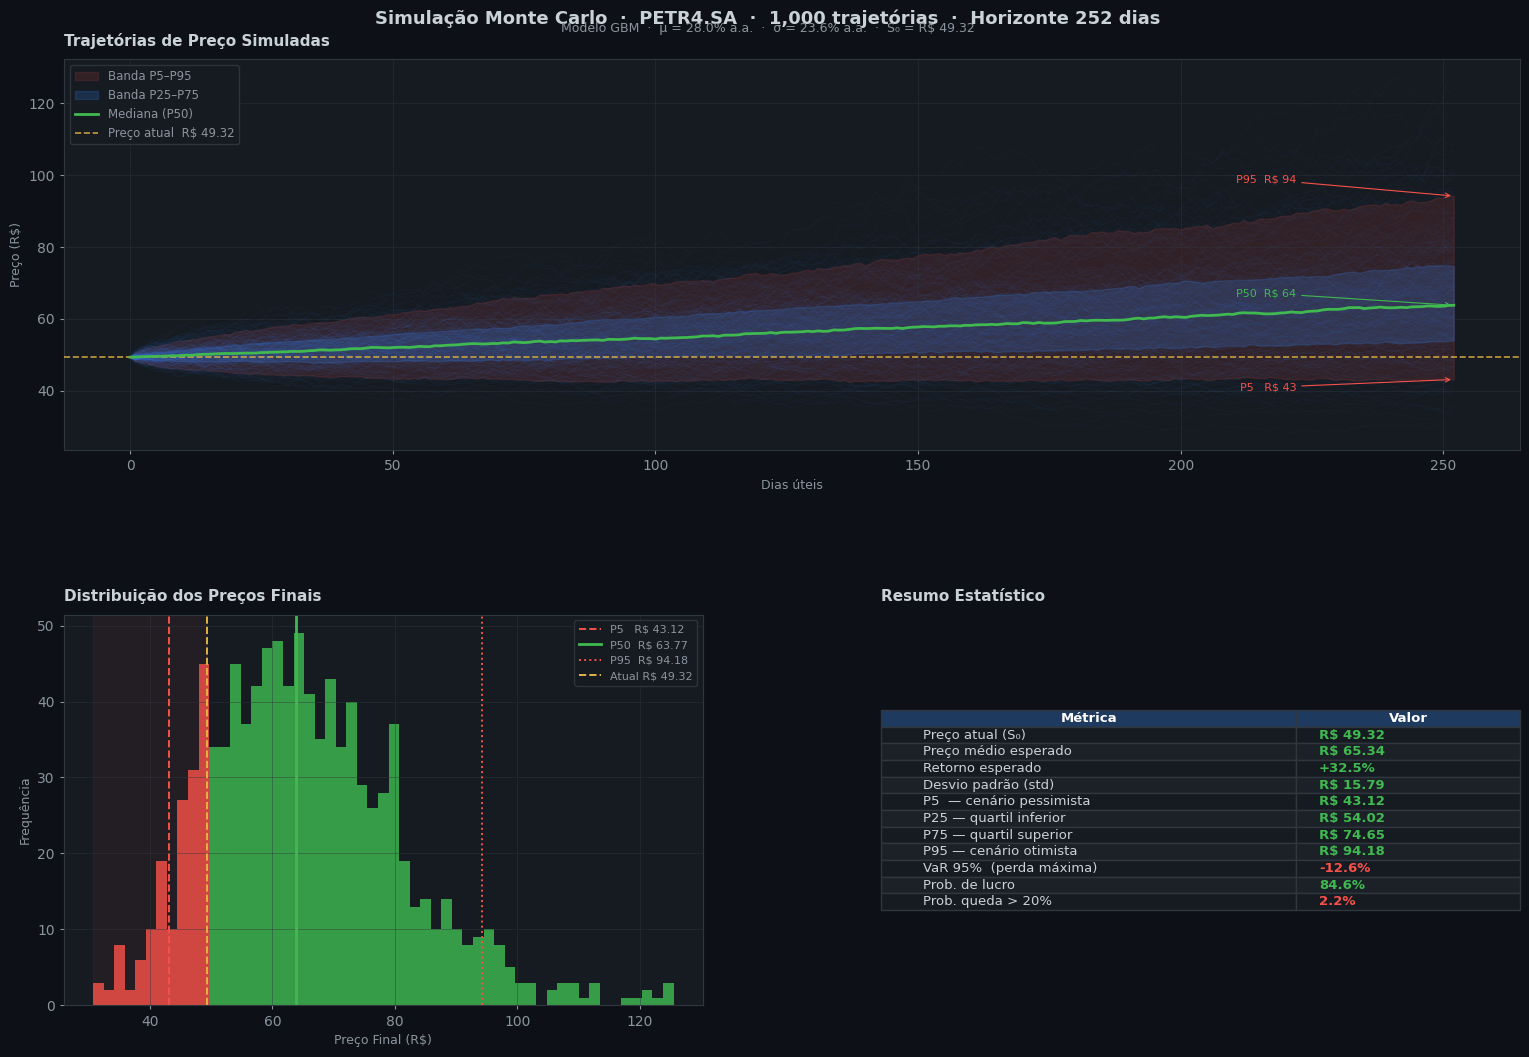

In [28]:
# ──────────────────────────────────────────────────────────────────────────────
#  PAINEL MONTE CARLO — tema dark
# ──────────────────────────────────────────────────────────────────────────────

# Paleta de cores
COR_FUNDO   = "#0d1117"
COR_GRADE   = "#161b22"
COR_BORDA   = "#30363d"
COR_TEXTO   = "#c9d1d9"
COR_TEXTO2  = "#8b949e"
COR_TRAJ    = "#388bfd"   # azul — trajetórias
COR_MED     = "#3fb950"   # verde — mediana
COR_BAND    = "#f85149"   # vermelho — banda P5-P95
COR_HIST_UP = "#3fb950"   # verde — lucro
COR_HIST_DN = "#f85149"   # vermelho — perda
COR_ATUAL   = "#e3b341"   # amarelo — linha preço atual
COR_HDR     = "#1f3a5f"   # azul escuro — cabeçalho da tabela


def estilizar(ax, titulo: str, xlabel: str = "", ylabel: str = ""):
    """Aplica o tema dark em qualquer eixo."""
    ax.set_facecolor(COR_GRADE)
    ax.set_title(titulo, color=COR_TEXTO, fontsize=11, fontweight="bold",
                 pad=10, loc="left")
    ax.tick_params(colors=COR_TEXTO2, labelcolor=COR_TEXTO2, length=3)
    ax.xaxis.label.set_color(COR_TEXTO2)
    ax.yaxis.label.set_color(COR_TEXTO2)
    if xlabel: ax.set_xlabel(xlabel, fontsize=9)
    if ylabel: ax.set_ylabel(ylabel, fontsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor(COR_BORDA)
    ax.grid(color=COR_BORDA, linewidth=0.5, alpha=0.6)


# ── Layout ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 11), facecolor=COR_FUNDO)
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.28,
                        left=0.06, right=0.97, top=0.93, bottom=0.07)

fig.suptitle(
    f"Simulação Monte Carlo  ·  {TICKER}  ·  {N_SIMULACOES:,} trajetórias  ·  Horizonte {DIAS_SIMULACAO} dias",
    color=COR_TEXTO, fontsize=13, fontweight="bold", x=0.5, y=0.975
)

# ── Subtítulo / linha decorativa ──────────────────────────────────────────────
fig.text(0.5, 0.955,
         f"Modelo GBM  ·  μ = {mu*252*100:.1f}% a.a.  ·  σ = {sigma*np.sqrt(252)*100:.1f}% a.a.  ·  S₀ = R$ {S0:.2f}",
         color=COR_TEXTO2, fontsize=9, ha="center")


# ══════════════════════════════════════════════════════════════════════════════
#  GRÁFICO 1 — Trajetórias simuladas (largura total)
# ══════════════════════════════════════════════════════════════════════════════
ax1 = fig.add_subplot(gs[0, :])
estilizar(ax1, "Trajetórias de Preço Simuladas", xlabel="Dias úteis", ylabel="Preço (R$)")

dias = np.arange(DIAS_SIMULACAO + 1)

# Plota subconjunto de trajetórias (evita sobrecarga visual)
n_exibir = min(300, N_SIMULACOES)
idx_exib = np.random.choice(N_SIMULACOES, n_exibir, replace=False)
for i in idx_exib:
    ax1.plot(dias, trajetorias[:, i], color=COR_TRAJ, alpha=0.04, linewidth=0.6)

# Calcula percentis por dia
p5_linha  = np.percentile(trajetorias, 5,  axis=1)
p95_linha = np.percentile(trajetorias, 95, axis=1)
med_linha = np.percentile(trajetorias, 50, axis=1)
p25_linha = np.percentile(trajetorias, 25, axis=1)
p75_linha = np.percentile(trajetorias, 75, axis=1)

# Bandas de confiança
ax1.fill_between(dias, p5_linha, p95_linha, alpha=0.12, color=COR_BAND,  label="Banda P5–P95")
ax1.fill_between(dias, p25_linha, p75_linha, alpha=0.18, color=COR_TRAJ, label="Banda P25–P75")

# Mediana e linha de referência
ax1.plot(dias, med_linha, color=COR_MED,   linewidth=2.0, label="Mediana (P50)", zorder=6)
ax1.axhline(S0, color=COR_ATUAL, linewidth=1.2, linestyle="--",
            alpha=0.85, label=f"Preço atual  R$ {S0:.2f}", zorder=5)

# Anotação no ponto final
ax1.annotate(f"P95  R$ {p95_linha[-1]:.0f}",
             xy=(DIAS_SIMULACAO, p95_linha[-1]), xytext=(DIAS_SIMULACAO - 30, p95_linha[-1] * 1.04),
             color=COR_BAND, fontsize=8, ha="right",
             arrowprops=dict(arrowstyle="->", color=COR_BAND, lw=0.8))
ax1.annotate(f"P50  R$ {med_linha[-1]:.0f}",
             xy=(DIAS_SIMULACAO, med_linha[-1]), xytext=(DIAS_SIMULACAO - 30, med_linha[-1] * 1.04),
             color=COR_MED, fontsize=8, ha="right",
             arrowprops=dict(arrowstyle="->", color=COR_MED, lw=0.8))
ax1.annotate(f"P5   R$ {p5_linha[-1]:.0f}",
             xy=(DIAS_SIMULACAO, p5_linha[-1]), xytext=(DIAS_SIMULACAO - 30, p5_linha[-1] * 0.93),
             color=COR_BAND, fontsize=8, ha="right",
             arrowprops=dict(arrowstyle="->", color=COR_BAND, lw=0.8))

legend1 = ax1.legend(
    facecolor=COR_GRADE, edgecolor=COR_BORDA,
    labelcolor=COR_TEXTO2, fontsize=8.5,
    loc="upper left", framealpha=0.9
)


# ══════════════════════════════════════════════════════════════════════════════
#  GRÁFICO 2 — Histograma dos preços finais
# ══════════════════════════════════════════════════════════════════════════════
ax2 = fig.add_subplot(gs[1, 0])
estilizar(ax2, "Distribuição dos Preços Finais", xlabel="Preço Final (R$)", ylabel="Frequência")

precos_finais = trajetorias[-1]

# Colore bins: verde = lucro, vermelho = perda
n_bins = 55
counts, bin_edges = np.histogram(precos_finais, bins=n_bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
cores_hist = [COR_HIST_UP if b > S0 else COR_HIST_DN for b in bin_centers]
ax2.bar(bin_centers, counts, width=(bin_edges[1] - bin_edges[0]),
        color=cores_hist, alpha=0.82, edgecolor="none")

# Linhas verticais de referência
ax2.axvline(stats["p5"],    color=COR_BAND,  linewidth=1.4, linestyle="--",
            label=f"P5   R$ {stats['p5']:.2f}")
ax2.axvline(stats["mediana"], color=COR_MED, linewidth=2.0, linestyle="-",
            label=f"P50  R$ {stats['mediana']:.2f}")
ax2.axvline(stats["p95"],   color=COR_BAND,  linewidth=1.4, linestyle=":",
            label=f"P95  R$ {stats['p95']:.2f}")
ax2.axvline(S0, color=COR_ATUAL, linewidth=1.4, linestyle="--",
            label=f"Atual R$ {S0:.2f}")

# Área sombreada da perda (VaR)
ax2.axvspan(precos_finais.min(), S0, alpha=0.06, color=COR_HIST_DN)

ax2.legend(facecolor=COR_GRADE, edgecolor=COR_BORDA,
           labelcolor=COR_TEXTO2, fontsize=8, framealpha=0.9)


# ══════════════════════════════════════════════════════════════════════════════
#  GRÁFICO 3 — Tabela de métricas
# ══════════════════════════════════════════════════════════════════════════════
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor(COR_GRADE)
ax3.axis("off")
ax3.set_title("Resumo Estatístico", color=COR_TEXTO, fontsize=11,
              fontweight="bold", pad=10, loc="left")

dados_tabela = [
    ["Preço atual (S₀)",       f"R$ {S0:.2f}"],
    ["Preço médio esperado",   f"R$ {stats['media']:.2f}"],
    ["Retorno esperado",       f"{stats['retorno_esperado']:+.1f}%"],
    ["Desvio padrão (std)",    f"R$ {stats['std']:.2f}"],
    ["P5  — cenário pessimista", f"R$ {stats['p5']:.2f}"],
    ["P25 — quartil inferior",  f"R$ {stats['p25']:.2f}"],
    ["P75 — quartil superior",  f"R$ {stats['p75']:.2f}"],
    ["P95 — cenário otimista",  f"R$ {stats['p95']:.2f}"],
    ["VaR 95%  (perda máxima)", f"{stats['var_95']:.1f}%"],
    ["Prob. de lucro",          f"{stats['prob_lucro']:.1f}%"],
    ["Prob. queda > 20%",       f"{stats['prob_queda_20']:.1f}%"],
]

tabela = ax3.table(
    cellText=dados_tabela,
    colLabels=["Métrica", "Valor"],
    cellLoc="left",
    loc="center",
    colWidths=[0.65, 0.35],
)
tabela.auto_set_font_size(False)
tabela.set_fontsize(9.5)

for (linha, col), cell in tabela.get_celld().items():
    cell.set_edgecolor(COR_BORDA)
    if linha == 0:
        # Cabeçalho
        cell.set_facecolor(COR_HDR)
        cell.set_text_props(color="white", fontweight="bold")
    elif linha % 2 == 0:
        cell.set_facecolor("#1c2128")
        cell.set_text_props(color=COR_TEXTO)
    else:
        cell.set_facecolor(COR_GRADE)
        cell.set_text_props(color=COR_TEXTO)
    # Coluna de valores em destaque
    if col == 1 and linha > 0:
        cell.set_text_props(color=COR_MED if linha not in [9, 11] else COR_BAND,
                            fontweight="bold")


# ── Salva e exibe ─────────────────────────────────────────────────────────────
plt.savefig("monte_carlo_resultado.png", dpi=150, bbox_inches="tight",
            facecolor=COR_FUNDO)
plt.show()

---

## Interpretação dos resultados

| Métrica | O que significa |
|---|---|
| **Retorno esperado** | Média dos retornos de todas as trajetórias no horizonte |
| **VaR 95%** | No pior cenário de 5% dos casos, a perda máxima esperada |
| **Prob. de lucro** | % de trajetórias que terminam acima do preço atual |
| **Banda P5–P95** | O preço ficará dentro deste intervalo em 90% dos cenários |
| **Prob. queda > 20%** | % de cenários com perda superior a 20% |

---

## Limitações do modelo

- O GBM assume volatilidade **constante** — na prática, ela muda (clusters de volatilidade)
- Não captura **eventos extremos** (crashes, gaps)
- Os parâmetros μ e σ são calibrados no passado — **não garantem** desempenho futuro
- Para precificação de opções, complementar com **modelo de Heston** (volatilidade estocástica)

---
*Desenvolvido como projeto de finanças quantitativas — Monte Carlo / GBM*